In [12]:
import pickle
import matplotlib.pyplot as plt
from pathlib import Path

DATA_RAW = Path("data_raw")

calce_file = list((DATA_RAW/"CALCE").rglob("*.pkl"))[0]

with open(calce_file, "rb") as f:
    calce_data = pickle.load(f)

print("Cell ID:", calce_data["cell_id"])
print("Nominal Capacity:", calce_data.get("nominal_capacity_in_Ah"))
print("Number of Cycles:", len(calce_data["cycle_data"]))

Cell ID: CALCE_CS2_33
Nominal Capacity: 1.1
Number of Cycles: 660


## CALCE Voltage Profile

This cell plots the **voltage profile for the first cycle** from the CALCE dataset.  
It helps visualize how voltage changes over time during a single battery cycle.

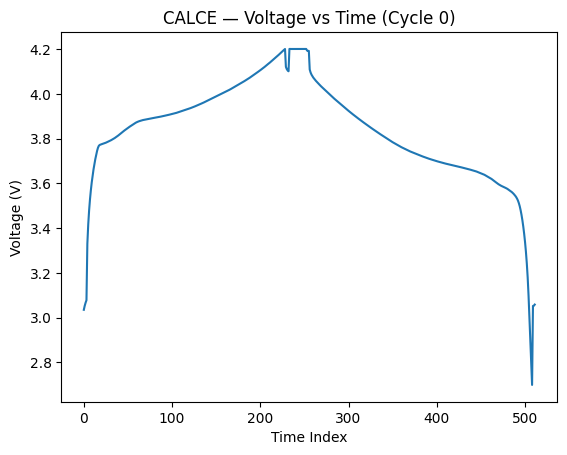

In [13]:
cycle_1 = calce_data["cycle_data"][0]

plt.figure()
plt.plot(cycle_1["voltage_in_V"])
plt.title("CALCE — Voltage vs Time (Cycle 0)")
plt.xlabel("Time Index")
plt.ylabel("Voltage (V)")
plt.show()

## CALCE Capacity Degradation

This cell extracts capacity values from the CALCE dataset and plots them across cycles.  
The plot shows **how battery capacity changes over time**, which helps visualize battery degradation.

In [18]:
capacities = []

for cycle in calce_data["cycle_data"]:
    if "capacity_in_Ah" in cycle:
        capacities.append(cycle["nominal_capacity_in_Ah"])

if len(capacities) > 0:
    plt.figure()
    plt.plot(capacities)
    plt.title("CALCE — Capacity Degradation")
    plt.xlabel("Cycle")
    plt.ylabel("Capacity (Ah)")
    plt.show()
else:
    print("Capacity field not found in CALCE cycles.")

Capacity field not found in CALCE cycles.


## Load Stanford Battery Dataset

This cell loads a Stanford battery dataset file (`.pkl`) from the `Stanford` folder inside `DATA_RAW`.

- The file is opened using `pickle.load()`.
- Key information about the battery cell is printed:
  - **Cell ID**
  - **Nominal Capacity (Ah)**
  - **Total number of cycles**

This helps verify the dataset structure and basic metadata before further analysis.

In [22]:
stanford_file = list((DATA_RAW/"Stanford").rglob("*.pkl"))[0]

with open(stanford_file, "rb") as f:
    stanford_data = pickle.load(f)

print("Cell ID:", stanford_data["cell_id"])
print("Nominal Capacity:", stanford_data.get("nominal_capacity_in_Ah"))
print("Number of Cycles:", len(stanford_data["cycle_data"]))

Cell ID: Stanford_Nova_Regular_191
Nominal Capacity: 0.24
Number of Cycles: 1042


## Voltage Profile Visualization

This cell plots the **voltage profile for the first cycle** in the Stanford battery dataset.

- The first cycle is extracted from `stanford_data["cycle_data"]`.
- The voltage values (`voltage_in_V`) are plotted against the time index.
- This visualization helps observe **voltage behavior during a single battery cycle**.

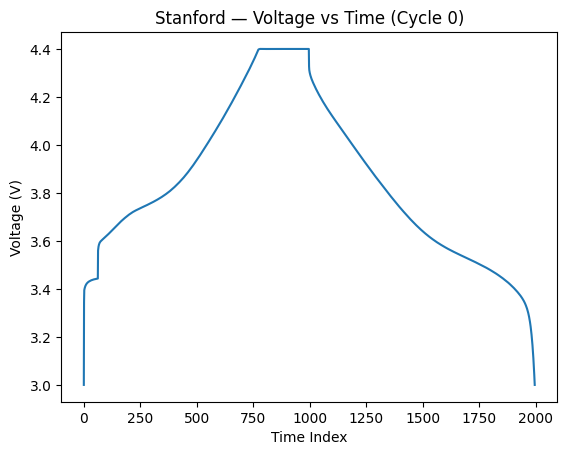

In [23]:
cycle_1 = stanford_data["cycle_data"][0]

plt.figure()
plt.plot(cycle_1["voltage_in_V"])
plt.title("Stanford — Voltage vs Time (Cycle 0)")
plt.xlabel("Time Index")
plt.ylabel("Voltage (V)")
plt.show()

## Capacity Degradation Visualization

This cell visualizes **battery capacity degradation across cycles** for the Stanford dataset.

- Capacity values are extracted from each cycle in `stanford_data["cycle_data"]`.
- If capacity data is available, it is plotted against cycle number.
- The resulting plot shows **how battery capacity decreases over time**, which is a key indicator of battery aging.

In [26]:
capacities = []

for cycle in stanford_data["cycle_data"]:
    if "capacity_in_Ah" in cycle:
        capacities.append(cycle["nominal_capacity_in_Ah"])

if len(capacities) > 0:
    plt.figure()
    plt.plot(capacities)
    plt.title("Stanford — Capacity Degradation")
    plt.xlabel("Cycle")
    plt.ylabel("Capacity (Ah)")
    plt.show()
else:
    print("Capacity field not found in Stanford cycles.")

Capacity field not found in Stanford cycles.
